# Real World Classification

## Load data

Import the necessary libraries

In [1]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

load the data

In [2]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


In [ ]:
# Check missing value column

# print(df.isnull().sum())
# print((df == 0).sum())
# print(df.isnull().any()) #boolean array
cols_with_missing = df.columns[df.isnull().any()|(df==0).any()]
print(cols_with_missing)


Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'BranchLength'],
      dtype='str')


In [8]:
print(df[cols_with_missing].median())
print(df[cols_with_missing].std())
df.describe()

SepalLengthCm     6.300000
SepalWidthCm      2.900000
PetalLengthCm     5.085612
PetalWidthCm      1.600000
BranchLength     16.300000
dtype: float64
SepalLengthCm    1.037115
SepalWidthCm     0.389564
PetalLengthCm    1.582807
PetalWidthCm     0.706689
BranchLength     1.035228
dtype: float64


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafShadowIndex,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex
count,500.000000,472.000000,443.000000,350.000000,478.000000,476.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,6.320551,2.837472,5.085612,1.675732,16.302941,46.745800,6.316422,6.323365,6.320980,...,0.032051,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674
std,144.481833,1.037115,0.389564,1.582807,0.706689,1.035228,30.032428,1.009859,1.043500,1.024075,...,0.962028,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-2.885405,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544
25%,125.750000,5.800000,2.600000,4.425000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.647824,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394
50%,250.500000,6.300000,2.900000,5.085612,1.600000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.028643,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542
75%,375.250000,6.700000,3.100000,5.500000,2.000000,16.800000,73.200000,6.738205,6.797044,6.699885,...,0.648784,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,2.918638,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291


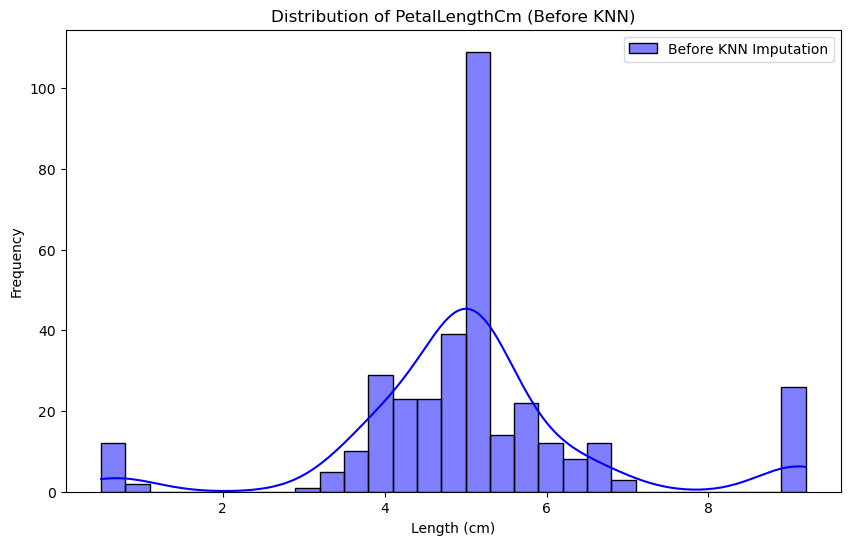

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# the column which lack the largest amount of value
sns.histplot(df['PetalLengthCm'], kde=True, color='blue', label='Before KNN Imputation')

plt.title('Distribution of PetalLengthCm (Before KNN)')
plt.xlabel('Length (cm)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## Data Preprocessing

In [21]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species']) #把種類變成數字（例如 0, 1, 2）

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]
    
    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce') #無法轉成數字的資料會強行變成 NaN
    
    
    # TODO: Replace the missing values using “Nearest Neighbors Imputation”
        
    # ---------- Start your code below ----------
        
    df[feature_cols] = df[feature_cols].replace(0, np.nan) #change 0 into NaN
    imputer = KNNImputer(n_neighbors=5)
    df[feature_cols] = imputer.fit_transform(df[feature_cols]) # use feature_cols because can reference all neighbors
        
    # ---------- --------------------- ----------
     
    return df, feature_cols

df, feature_cols = data_preprocessing(df)

In [24]:
# print(data.columns[data.isnull().any()]) #Check no missing value
print(df[cols_with_missing].median())
print(df[cols_with_missing].std())
df.describe()

SepalLengthCm     6.300000
SepalWidthCm      2.900000
PetalLengthCm     5.035683
PetalWidthCm      1.700000
BranchLength     16.300000
dtype: float64
SepalLengthCm    1.009275
SepalWidthCm     0.372434
PetalLengthCm    1.514955
PetalWidthCm     0.686353
BranchLength     1.011012
dtype: float64


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.319840,2.837040,5.049883,1.688920,16.303440,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.009275,0.372434,1.514955,0.686353,1.011012,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.630000,4.500000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.035683,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.040000,5.300000,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


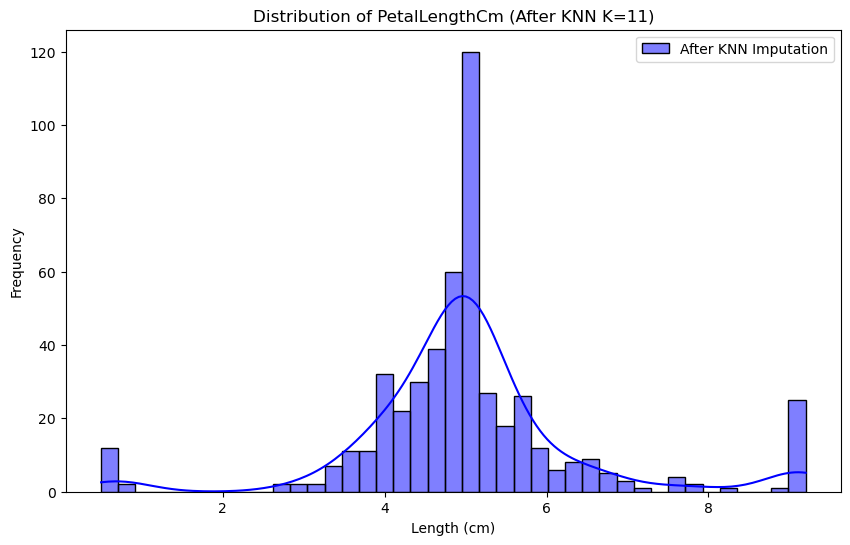

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# 畫出補值後的分佈 (使用透明度 alpha 觀察層次)
sns.histplot(df['PetalLengthCm'], kde=True, color='blue', label='After KNN Imputation')

plt.title('Distribution of PetalLengthCm (After KNN K=11)')
plt.xlabel('Length (cm)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## Data Exploration

In [6]:
from sklearn.feature_selection import r_regression

# TODO: Complete the 4. Data Exploration

## Model Training

### Prepare the data

In [7]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0
        
X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.608,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.616,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


### Train the model!

50. Training loss: 0.6200853537083829, Val loss:0.6391812696784778
100. Training loss: 0.5999140020155088, Val loss:0.6249866197234236
150. Training loss: 0.5845521256358253, Val loss:0.6144525144085324
200. Training loss: 0.5726091617753163, Val loss:0.6065178968411462
250. Training loss: 0.5631618029385184, Val loss:0.6004684021834675
300. Training loss: 0.5555792312387682, Val loss:0.5958106599896559
350. Training loss: 0.5494186018263224, Val loss:0.5921960224864331
400. Training loss: 0.544361261553348, Val loss:0.589373119251429
450. Training loss: 0.540172836728758, Val loss:0.5871575502695907
500. Training loss: 0.5366775872259685, Val loss:0.5854120178132641
550. Training loss: 0.5337414942704376, Val loss:0.5840329823158672
600. Training loss: 0.531260831692745, Val loss:0.5829415005023532
650. Training loss: 0.5291542670617071, Val loss:0.5820768098307887
700. Training loss: 0.5273572898169104, Val loss:0.5813917567396144
750. Training loss: 0.525818207770468, Val loss:0.580

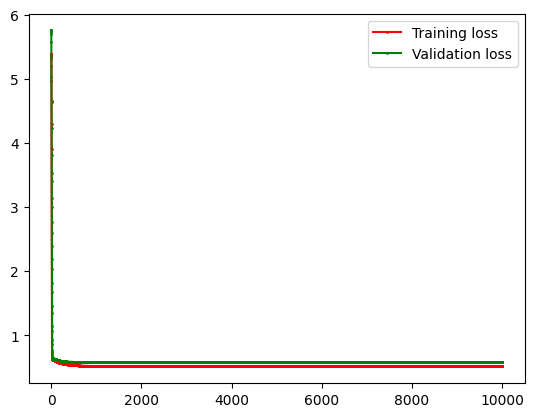

Model parameters (weights): [[-4.49405480e-01]
 [ 3.67848700e-01]
 [ 1.15869330e-01]
 [ 6.82788546e-02]
 [ 6.18110098e-01]
 [ 2.64160968e-01]
 [ 1.80442041e-01]
 [ 2.46564788e-01]
 [ 2.76734659e-01]
 [ 3.67338561e-01]
 [ 3.06677080e-01]
 [ 3.05728801e-01]
 [ 3.53685825e-01]
 [ 2.70833684e-02]
 [-5.78283231e-02]
 [ 7.55209303e-02]
 [ 1.43102508e-01]
 [ 1.24444996e-01]
 [ 9.33699549e-02]
 [ 1.45389667e-01]
 [ 1.90622477e-01]
 [ 2.24987080e-01]
 [ 1.57683848e-01]
 [ 2.08656224e-01]
 [ 1.64739306e-01]
 [ 6.27459032e-01]
 [ 6.38855739e-01]
 [ 6.51313576e-01]
 [ 6.58636665e-01]
 [ 6.68895439e-01]
 [ 6.53338234e-01]
 [-4.57975496e-01]
 [ 1.71897765e-01]
 [-1.73183641e-01]
 [-3.16018080e-02]
 [-2.26051838e-01]
 [ 5.41542116e-05]
 [-3.27300431e-01]
 [-7.96180046e-01]
 [-1.38822099e-01]
 [-3.40661976e-01]
 [-1.56784344e-01]
 [-4.14330502e-01]
 [-2.88541967e-01]
 [ 2.47159370e-02]
 [-1.87650720e-01]
 [-1.66915714e-01]
 [-1.35203206e-01]
 [-2.66198513e-01]
 [-2.64137133e-01]
 [-1.45897118e-01]
 [-

In [ ]:
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

np.random.seed(seed)
model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
model.fit(X_train, y_train,lr=0.1, n_iteration =10000,val_ratio=0.2, reg_type='', reg_lambda=0.0)

# print model parameters
print("Model parameters (weights):", model.W)
# sum of absolute values of weights
print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))

## Metrics

Model Evaluation
Accuracy  : 0.7533
Precision : 0.7294
Recall    : 0.8158
F1-score  : 0.7702


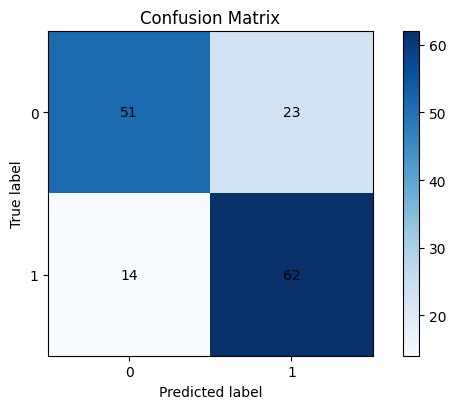

{'Accuracy': 0.7533333333333333,
 'Precision': 0.7294117647058823,
 'Recall': 0.8157894736842105,
 'F1-score': 0.7701863354037267}

In [34]:
# use evaluate_binary_classifier to evaluate the model on the test set
from model.metrics import evaluate_binary_classifier

y_pred = model.predict(X_test)
evaluate_binary_classifier(y_test, y_pred)